# Root-Cause Analysis Triage Report

The explanation analysis converts the selected model into a ranked set of sensor investigation candidates. The results are empirical attribution and distribution signals from the current model and processed test split; they identify where the model finds failure-related structure, not confirmed physical root causes.

The strongest composite candidates are `sensor_059`, `sensor_033`, `sensor_519`, `sensor_205`, and `sensor_031`. These sensors combine high SHAP attribution, fail/pass attribution differences, and SPC flag behavior more strongly than the rest of the feature set. `sensor_059` leads by a wide margin on every signal.

## Data and Model Context

The analysis uses the selected model from notebook 04 (`models/selected_model.joblib`, a tuned random forest) and the same processed train/test data. The test set contains 314 wafers and 198 sensor features. Because notebook 04 showed limited predictive strength, the ranked sensors below are best interpreted as prioritization evidence for engineering review rather than final causal assignments.

In [1]:
from __future__ import annotations

import contextlib
import io
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from yield_risk.config import load_config
from yield_risk.explainability import compute_shap_values, global_feature_importance, save_shap_values
from yield_risk.root_cause import fail_shap_lift, rank_root_cause_candidates, spc_flag_rate

In [2]:
cfg = load_config(ROOT / "configs" / "config.yaml")

model_path = ROOT / "models" / "selected_model.joblib"
train_path = ROOT / "data" / "processed" / "train.csv"
test_path = ROOT / "data" / "processed" / "test.csv"

required_paths = [model_path, train_path, test_path]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Model and processed data artifacts are required. Missing: "
        + ", ".join(str(path) for path in missing_paths)
    )

pipeline = joblib.load(model_path)
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

sensor_cols = [column for column in test.columns if column.startswith("sensor_")]
if not sensor_cols:
    raise ValueError("No sensor_* columns found in processed test data.")

X_train = train[sensor_cols]
X_test = test[sensor_cols]
y_test = test["label"].to_numpy()

print(f"Loaded selected model: {model_path}")
print(f"Classifier: {type(pipeline.named_steps['classifier']).__name__}")
print(f"Train rows: {len(train):,}; test rows: {len(test):,}; sensors: {len(sensor_cols):,}")

Loaded selected model: C:\Users\Virgil\Code\semiconductor-yield-root-cause\models\selected_model.joblib
Classifier: RandomForestClassifier
Train rows: 1,253; test rows: 314; sensors: 198


## Explanation Signals

Three signals are combined for each sensor: mean absolute SHAP value, fail/pass SHAP lift, and SPC flag rate. Mean absolute SHAP measures how strongly the model uses a sensor overall. SHAP lift measures whether attribution differs between failing and passing wafers. SPC flag rate measures how often the sensor falls outside a simple mean plus or minus three-sigma band.

The composite score emphasizes sensors that are important to the model, differ by outcome class, and show some statistical process-control abnormality in the held-out data.

In [3]:
shap_stdout = io.StringIO()
with contextlib.redirect_stdout(shap_stdout), contextlib.redirect_stderr(shap_stdout):
    explanations = compute_shap_values(pipeline, X_train, X_test)
global_importance = global_feature_importance(explanations)
flag_rates = spc_flag_rate(test, sensor_cols)
shap_lift = fail_shap_lift(explanations, y_test)
candidates = rank_root_cause_candidates(global_importance, shap_lift, flag_rates)

print(
    f"Computed SHAP explanations for {len(X_test):,} test rows "
    f"and {len(sensor_cols):,} sensor features."
)
print(
    "Composite ranking combines mean absolute SHAP, fail/pass SHAP lift, "
    "and SPC flag rate."
)
candidates.head(15)

Computed SHAP explanations for 314 test rows and 198 sensor features.
Composite ranking combines mean absolute SHAP, fail/pass SHAP lift, and SPC flag rate.


,sensor,mean_abs_shap,shap_lift,spc_flag_rate,composite_score
0,sensor_059,0.005736,0.010661,0.019108,0.870588
1,sensor_033,0.004237,0.001798,0.015924,0.478730
2,sensor_519,0.003236,0.001961,0.025478,0.431327
3,sensor_205,0.003943,0.000984,0.003185,0.383114
4,sensor_031,0.003974,-0.000374,0.000000,0.356939
5,sensor_510,0.002534,0.001027,0.015924,0.308605
6,sensor_064,0.002483,0.000785,0.015924,0.297348
7,sensor_129,0.002702,0.001659,0.000000,0.282234
8,sensor_065,0.002187,0.000922,0.015924,0.275410
9,sensor_160,0.001404,0.000221,0.035032,0.258035


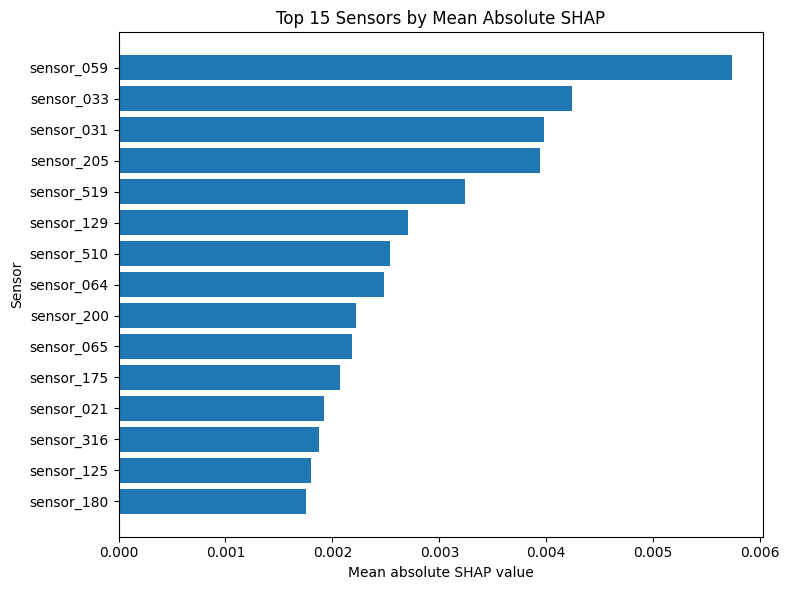

In [4]:
top_n = 15
top_importance = global_importance.head(top_n).sort_values("mean_abs_shap")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_importance["feature"], top_importance["mean_abs_shap"])
ax.set_title(f"Top {top_n} Sensors by Mean Absolute SHAP")
ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("Sensor")
plt.tight_layout()

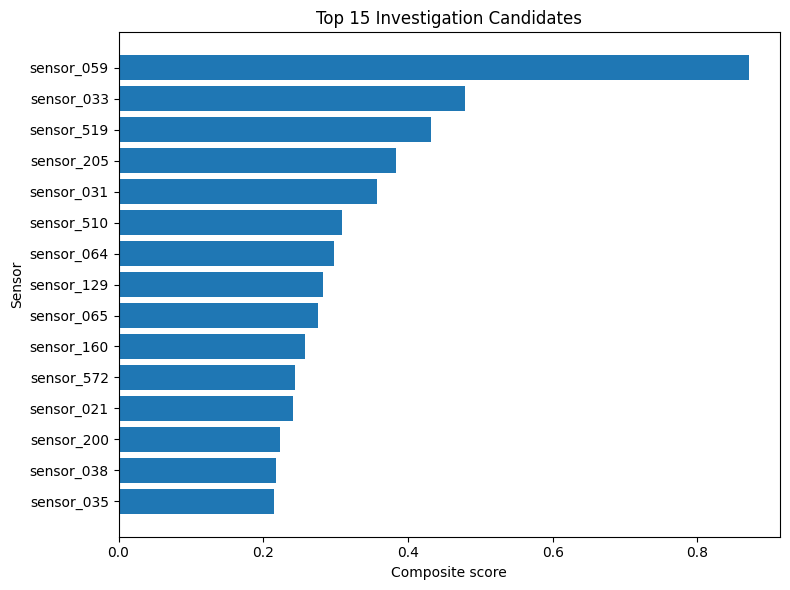

In [5]:
top_candidates = candidates.head(top_n).sort_values("composite_score")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_candidates["sensor"], top_candidates["composite_score"])
ax.set_title(f"Top {top_n} Investigation Candidates")
ax.set_xlabel("Composite score")
ax.set_ylabel("Sensor")
plt.tight_layout()

## Candidate Distribution Review

The top-ranked candidates have mixed evidence. `sensor_059` dominates the composite score: it has the largest mean absolute SHAP value, a positive fail/pass SHAP lift, and a ~1.9% SPC flag rate. `sensor_033` is a clear second on SHAP attribution, while `sensor_519` ranks highly largely on its SPC flag rate. The distribution plots compare pass and fail density directly, exposing whether these rankings reflect broad separation or a small number of tail observations.

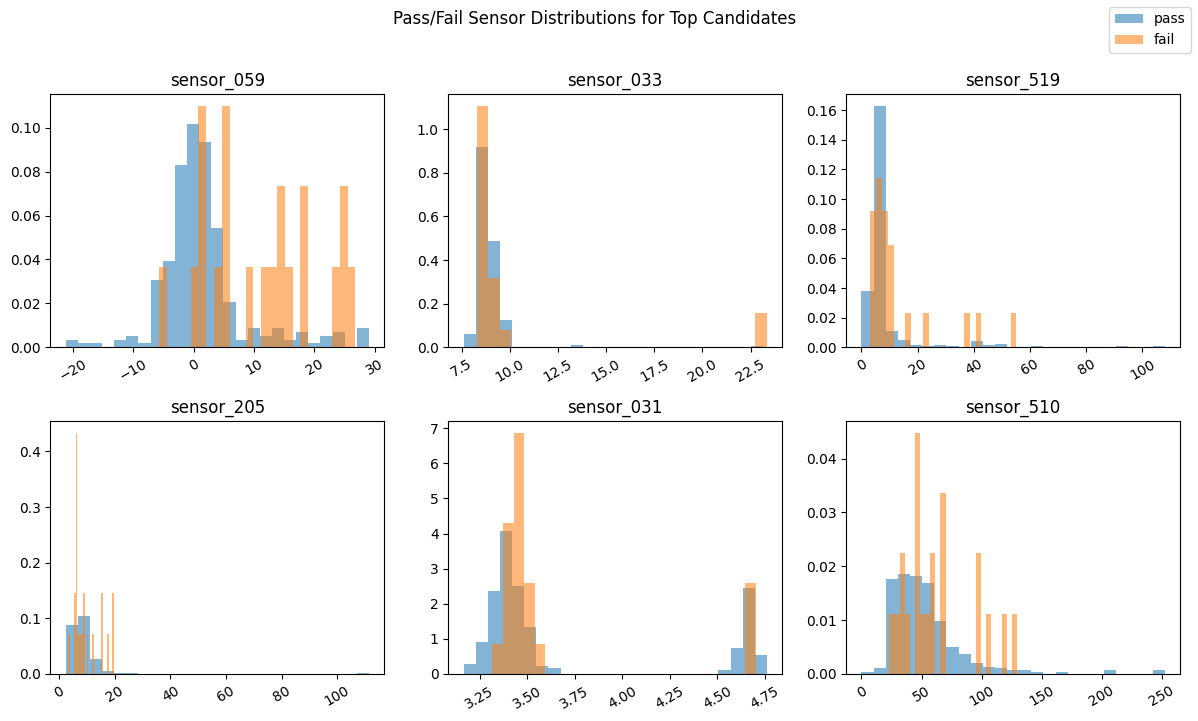

In [6]:
sensors_to_plot = candidates.head(6)["sensor"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, sensor in zip(axes.ravel(), sensors_to_plot, strict=False):
    passing = test.loc[test["label"] == 0, sensor].dropna()
    failing = test.loc[test["label"] == 1, sensor].dropna()
    ax.hist(passing, bins=25, alpha=0.55, label="pass", density=True)
    ax.hist(failing, bins=25, alpha=0.55, label="fail", density=True)
    ax.set_title(sensor)
    ax.tick_params(axis="x", labelrotation=30)

for ax in axes.ravel()[len(sensors_to_plot):]:
    ax.axis("off")

handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Pass/Fail Sensor Distributions for Top Candidates", y=1.02)
plt.tight_layout()

## Persisted Review Artifacts

The SHAP values, global SHAP importance, and ranked root-cause candidate table are stored in `reports/`. These artifacts preserve the exact attribution results used in this report and provide the tabular inputs for follow-up process analysis.

In [7]:
reports_dir = ROOT / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

save_shap_values(explanations, reports_dir / "shap_values.npz")
global_importance.to_csv(reports_dir / "shap_global_importance.csv", index=False)
candidates.to_csv(reports_dir / "root_cause_candidates.csv", index=False)

print(f"Saved review artifacts to {reports_dir}")

Saved review artifacts to C:\Users\Virgil\Code\semiconductor-yield-root-cause\reports


## Empirical Interpretation

The root-cause triage output is consistent with the modeling limits observed in notebook 04, and it agrees with that notebook's model-based importance from an independent method. The random forest's impurity importance and the SHAP global ranking both place `sensor_059` and `sensor_033` at the very top, with `sensor_205`, `sensor_510`, and `sensor_031` also appearing in both views. That cross-method agreement strengthens their value as investigation candidates.

The evidence remains correlational. The selected model has low precision and only moderate recall at its cost-optimal threshold, so these rankings are a short list for engineering validation — a place to start asking *why* a sensor reads the way it does (tool drift, recipe deviation, contamination), not a causal verdict. A physically credible root-cause conclusion would require persistence across time, lots, tools, or process context beyond the sensor-only model outputs shown here.